# Support Vector Classifier

see: pdf in doc!

In [34]:
import numpy as np

# generate 2 classes
np.random.seed(5)
X = np.random.randn(20, 2)
y = np.repeat([1, -1], 10)
X[y == -1] = X[y == -1] + 1

Text(0, 0.5, 'X2')

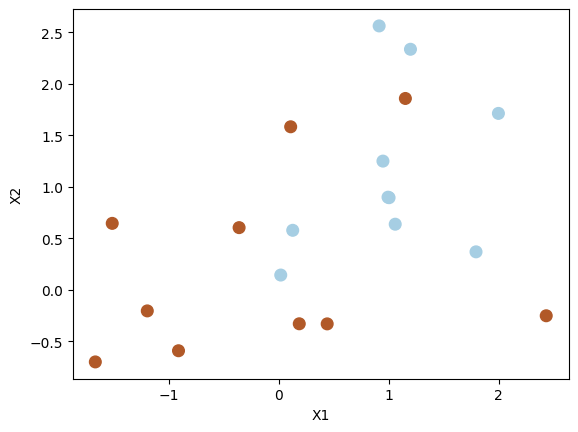

In [35]:

from matplotlib import pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s=70, c=y, cmap='Paired')
plt.xlabel('X1')
plt.ylabel('X2')

In [36]:
from sklearn.svm import SVC

svc = SVC(C=1, kernel='linear')
svc.fit(X, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
import numpy as np
import matplotlib.pyplot as plt


def plot_svc(svc, X, y, h=0.02, pad=0.25):
    # Ensure X is a numpy array to avoid issues with pandas DataFrames
    X = np.asarray(X)

    # Calculate axis limits
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad

    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict class labels for each point in the mesh
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, cmap='Paired', alpha=0.2)

    # Plot the training points
    # Note: 'c=y' works best when y is numeric (e.g., 0 and 1).
    # Added edgecolor='k' to make points stand out against the background.
    plt.scatter(X[:, 0], X[:, 1], s=70, c=y, cmap='Paired', edgecolor='k')

    # Support vectors indicated by 'x' markers
    sv = svc.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], c='k', marker='x', s=100, linewidths=1)

    # Formatting
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Feature 1 (X1)')
    plt.ylabel('Feature 2 (X2)')
    plt.title('SVM Decision Boundary')
    plt.show()

    print(f'Number of support vectors: {len(sv)}')

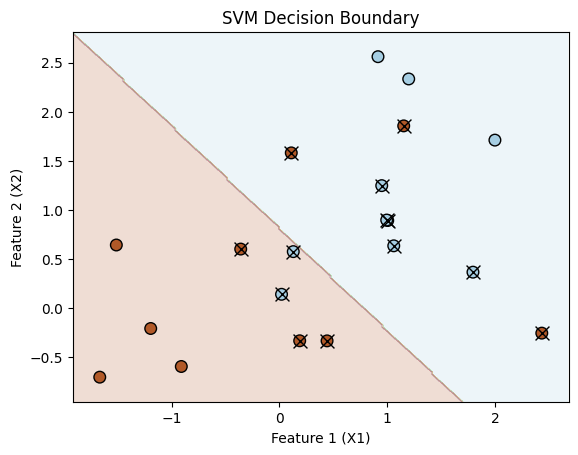

Number of support vectors: 13


In [38]:
plot_svc(svc, X, y)

In [39]:
svc.support_

array([10, 11, 13, 14, 15, 16, 17,  0,  1,  2,  4,  6,  8], dtype=int32)

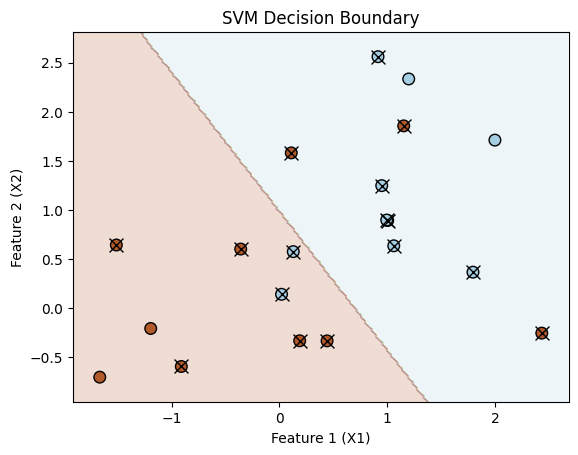

Number of support vectors: 16


In [41]:
# c = cost parameter
# Now that a smaller value of the c parameter is being used, we obtain a larger number of support vectors, because the margin is now wider.

svc2 = SVC(C=0.1, kernel='linear')
svc2.fit(X, y)
plot_svc(svc2, X, y)

In [52]:
from sklearn.model_selection import GridSearchCV

# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10, scoring='accuracy', verbose=3)
clf.fit(X, y)

Fitting 10 folds for each of 7 candidates, totalling 70 fits
[CV 1/10] END ..........................C=0.001;, score=0.500 total time=   0.0s
[CV 2/10] END ..........................C=0.001;, score=0.500 total time=   0.0s
[CV 3/10] END ..........................C=0.001;, score=0.500 total time=   0.0s
[CV 4/10] END ..........................C=0.001;, score=1.000 total time=   0.0s
[CV 5/10] END ..........................C=0.001;, score=1.000 total time=   0.0s
[CV 6/10] END ..........................C=0.001;, score=1.000 total time=   0.0s
[CV 7/10] END ..........................C=0.001;, score=1.000 total time=   0.0s
[CV 8/10] END ..........................C=0.001;, score=1.000 total time=   0.0s
[CV 9/10] END ..........................C=0.001;, score=0.500 total time=   0.0s
[CV 10/10] END .........................C=0.001;, score=1.000 total time=   0.0s
[CV 1/10] END ...........................C=0.01;, score=0.500 total time=   0.0s
[CV 2/10] END ...........................C=0.01;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.001, 0.01, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy us

In [55]:
print(clf.best_params_)
print(clf.best_estimator_)
print(clf.best_score_)

{'C': 0.001}
SVC(C=0.001, kernel='linear')
0.8


### Predict

In [56]:
np.random.seed(1)
X_test = np.random.randn(20, 2)
y_test = np.random.choice([-1, 1], 20)
X_test[y_test == 1] = X_test[y_test == 1] - 1

In [57]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# With this value of c, 14 of the test observations are correctly classified.

svc2 = SVC(C=0.001, kernel='linear')
svc2.fit(X, y)
y_pred = svc2.predict(X_test)
pd.DataFrame(confusion_matrix(y_test, y_pred), index=svc2.classes_, columns=svc2.classes_)

,-1,1
-1,2,6
1,0,12


Text(0, 0.5, 'X2')

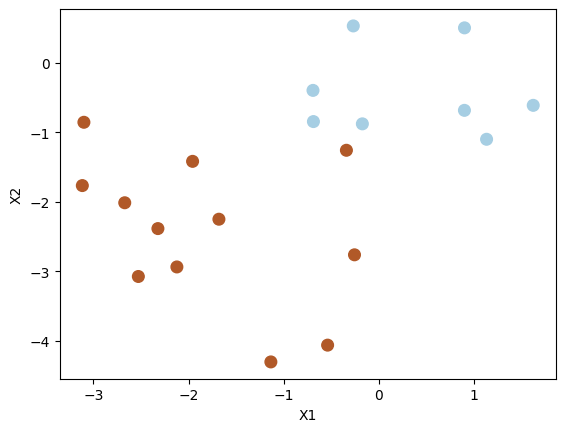

In [58]:
X_test[y_test == 1] = X_test[y_test == 1] - 1
plt.scatter(X_test[:, 0], X_test[:, 1], s=70, c=y_test, cmap='Paired')
plt.xlabel('X1')
plt.ylabel('X2')

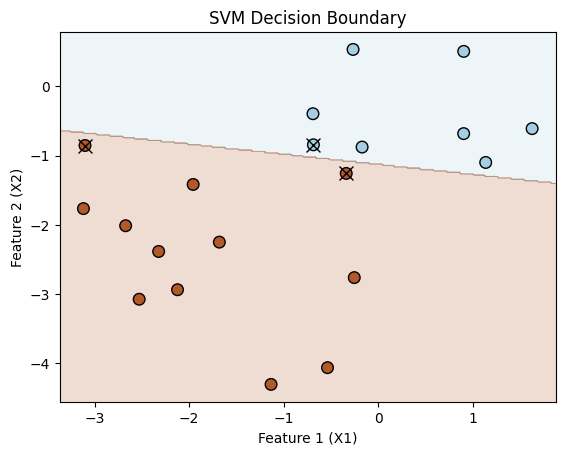

Number of support vectors: 3


In [59]:
svc3 = SVC(C=1e5, kernel='linear')
svc3.fit(X_test, y_test)
plot_svc(svc3, X_test, y_test)

# No training errors were made and only three support vectors were used.
# However, we can see from the figure that the margin is very narrow (because the observations that are not support vectors, indicated as circles, are very close to the decision boundary).
# It seems likely that this model will perform poorly on test data.

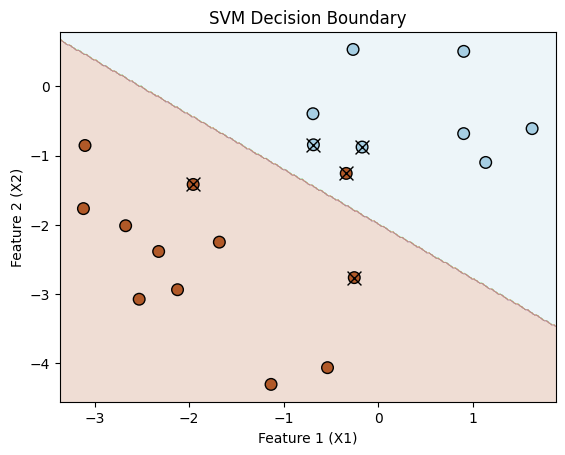

Number of support vectors: 5


In [60]:
svc4 = SVC(C=1, kernel='linear')
svc4.fit(X_test, y_test)
plot_svc(svc4, X_test, y_test)

# Using cost = 1,we misclassify a training observation, but we also obtain a much wider margin and make use of five support vectors.
# It seems likely that this model will perform better on test data.